# Phase Three: Finding Anomaly Years

## Libraries

In [1]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [133]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="muted")

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest

from data import utils

## Load Data

In [88]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])


In [89]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])

eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

In [90]:
def get_interpolated_df(spectral, timestamps):
    spectral_columns = [
        'NDVI_mean',
        'NDWI_mean',
        'NDRE_mean',
        'NDVI_std',
        'NDWI_std',
        'NDRE_std',
    ]

    df = spectral.merge(timestamps, on="Timestamp", how="right")
    interpolated_df = df[["Timestamp"] + spectral_columns].copy()
    interpolated_df[spectral_columns] = interpolated_df[spectral_columns].interpolate(method="pchip", limit_area="inside").bfill()

    return interpolated_df.dropna()

---

## Per-year analysis

### Summary Statistics

A good first approach to looking at how our growing seasons are distributed is considering the sample mean, cummulation or order statistics of specific features. This will give us a good idea of which years deviate from an expected trend.

In [115]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    "Shallow_mean",
    'Ag_year',
    'shifted_doy',
    
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
    'NDVI_std',
    'NDWI_std',
    'NDRE_std',
]

In [116]:
# Get df containing above features

interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]

In [117]:
grouped = summary_df.drop('shifted_doy', axis=1).groupby("Ag_year")

agg = grouped.agg({
    "precipitation": "sum",
    "temperature_2m": "mean",
    "root_weighted_soil_moisture": "mean",
    "cumulative_GDD": "max",
    "NDVI_mean": "mean",
    "NDWI_mean": "mean",
    "NDRE_mean": "mean",
}).reset_index()
agg

,Ag_year,precipitation,temperature_2m,root_weighted_soil_moisture,cumulative_GDD,NDVI_mean,NDWI_mean,NDRE_mean
0,2018,616.547833,290.730678,0.287340,1926.859178,0.409582,0.067484,0.271515
1,2019,537.903352,289.719104,0.293197,1702.141394,0.429904,0.116318,0.282203
2,2020,669.932304,289.138301,0.377099,1546.787355,0.456460,0.171278,0.299337
3,2021,686.550234,288.681646,0.366703,1439.989890,0.462735,0.148522,0.301380
4,2022,698.384335,288.895480,0.368016,1477.107679,0.468064,0.164780,0.302569
5,2023,595.111969,290.256479,0.302184,1820.998342,0.429436,0.096275,0.281179
6,2024,823.606560,289.551048,0.366058,1668.667770,0.468810,0.162550,0.296305


From this summary table, we conclude the following:
- **Total precipitation** has strong fluctuations, with a _low_ of $538$mm (2019), $595$mm (2023) and a _high_ of ~$824$mm for 2024.
- **NDWI** can be seen as a water stress proxy, with a strong dip in 2018 at $0.067$ and 2023 at $0.096$. 2019 also has a noteworthy low NDWI value.
- The highest cumulative GDD seasons are 2018 and 2023 with values ~$1927$ and ~$1821$ respectively. Since each season has the same End of Season (EoS) DOY by design, 2018 and 2023 consistently had higher heat-accumulation. 

We can come to the conclustion that 2018 and 2023 are our most stressed seasons, with 2019 a close third place. Stress in this case is defined as heat-accumulation and drought.

### NDVI

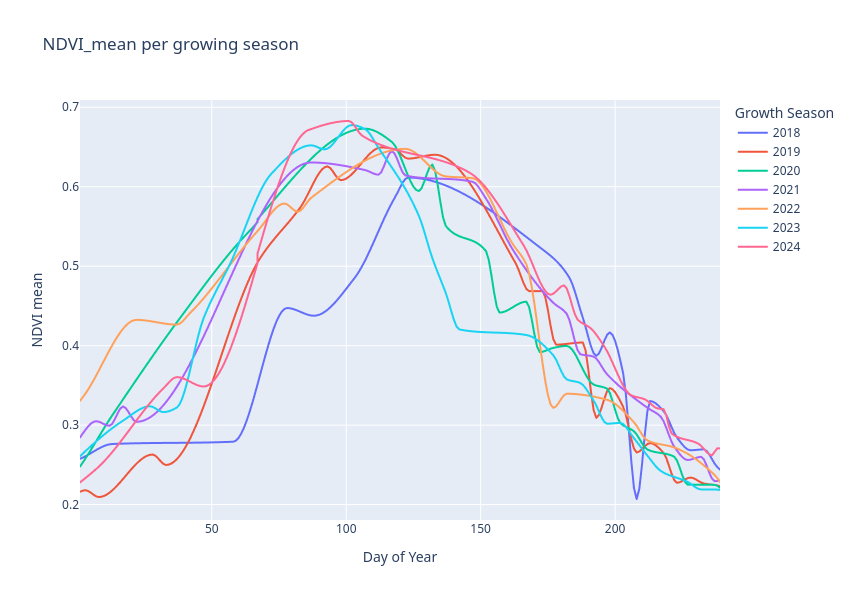

In [118]:

fig = px.line(
    summary_df, 
    x="shifted_doy", 
    y="NDVI_mean", 
    color="Ag_year",
    title="NDVI_mean per growing season",
    labels={"shifted_doy": "Day of Year", "NDVI_mean": "NDVI mean", "Ag_year": "Growth Season"},
    template="plotly_white",
    height=600,
    width=1000,
)
fig.update_layout(template="plotly")
fig.update_layout(hovermode="x unified")


fig.show()

### Z-scores

A useful processing technique is calculating the $Z$-scores of _each feature_, grouped over our defined growing seasons. More specifically, if $\textbf{x}_\text{year}$ represents a **feature vector** in a specific growing season, we scale and standardise each feature $j=1,2,...,p$ so that its mean is $0$ and variance is $1$. 
$$
z_{\text{year},j} = \frac{x_{\text{year}, j}-\bar{x}_{\text{year},j}}{s_{\text{year}, j}}
$$

This removes seasonal scale differences, allowing for the comparison of features across _seasons_. We first show the usefulness with a heatmap: 

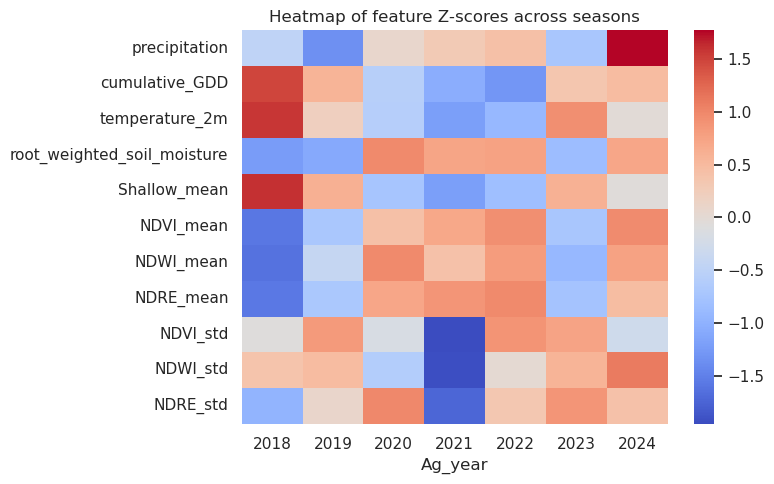

In [120]:
yearly = summary_df.groupby("Ag_year")[eng_features[:-2] + spectral_features].mean()
yearly_z = (yearly - yearly.mean()) / yearly.std()

plt.figure(figsize=(8, 5))
plt.title("Heatmap of feature Z-scores across seasons")
sns.heatmap(yearly_z.T, cmap="coolwarm")
plt.tight_layout()
plt.show()

Here we can find which variables were unusally high/low relative to each season's own baseline. We again see the pattern we found in the summary statistics:
- 2018-2019 have _strong_ **positive** deviation from their own baselines for air temperature, shallow soil temperature and cummulative GDD.
- 2018-2019 have **negative** deviations from their baselines for precipitation, $\text{NDWI}$ and root weighted soil moisture (water uptake of roots from soil, dependent on growth stage). Additionally, vegetation indices like $\text{NDRE}/\text{NDVI}$ also have _strong_ negative deviations, suggesting crop stress.
- 2020-2022, 2025 are recovery periods.
- 2023 again shows signs of stress, with **negative** deviations from the spectral indices $\text{NDWI}$ (water proxy), $\text{NDRE}$ / $\text{NDVI}$ (greenness/chlorophyl), suggesting stress in the vegetation.

We can make these deviations slightly more interpretable with barplots:

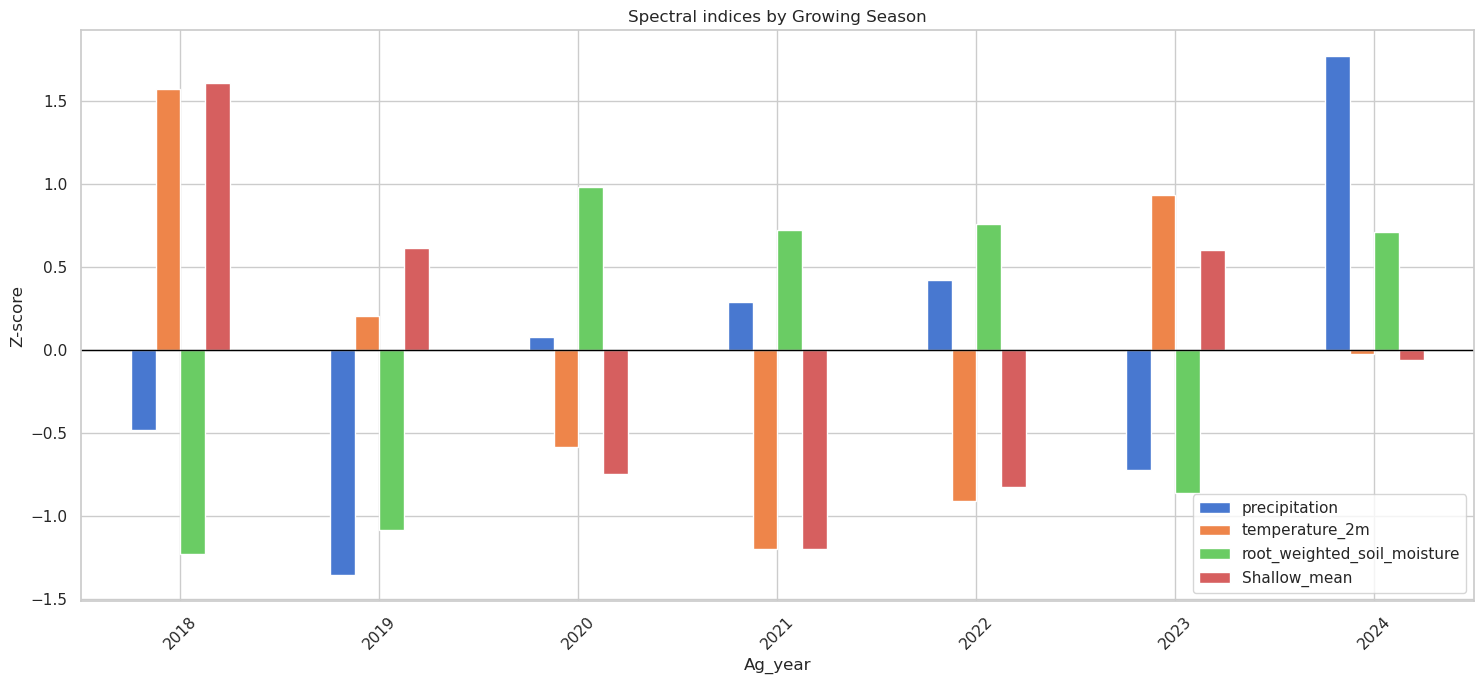

In [126]:
selected = ["precipitation", "temperature_2m", "root_weighted_soil_moisture", "Shallow_mean"]

yearly_z[selected].plot(kind="bar", figsize=(15, 7))
plt.axhline(0, color="black", linewidth=1)
plt.title("Spectral indices by Growing Season")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PCA

In [150]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    'Shallow_mean',
    "ST_PC1",
    "VW_PC1",
    "Ag_year"
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
]

In [151]:
interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]
summary_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,NDVI_std,NDWI_std,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,...,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
299,2018-10-27,0.257591,-0.072709,0.169299,0.009598,0.001395,0.006549,0.251256,0.275675,0.275435,...,1,2018,1,10.490344,10.490344,SoS,0.0,-1.506865,294.371702,1.627398
300,2018-10-28,0.259027,-0.071103,0.170494,0.009517,0.002113,0.006422,0.248644,0.273228,0.274899,...,2,2018,1,10.933870,21.424214,SoS,0.0,-1.558094,294.913417,1.835885
301,2018-10-29,0.260717,-0.069631,0.171896,0.009444,0.002956,0.006308,0.247455,0.271179,0.274380,...,3,2018,1,12.442943,33.867157,SoS,0.0,-1.591530,295.499277,2.057644
302,2018-10-30,0.262590,-0.068287,0.173448,0.009380,0.003889,0.006205,0.245628,0.269480,0.273886,...,4,2018,1,13.618227,47.485384,SoS,0.0,-1.627229,295.687618,2.143829
303,2018-10-31,0.264579,-0.067063,0.175089,0.009325,0.004875,0.006114,0.251036,0.268644,0.273621,...,5,2018,1,7.498077,54.983462,SoS,0.0,-1.584987,293.745396,1.480230


In [152]:
pca = PCA()
scaler = StandardScaler()

X = summary_df[eng_features + spectral_features].groupby("Ag_year").mean() 
X_scaled = scaler.fit_transform(X)

pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

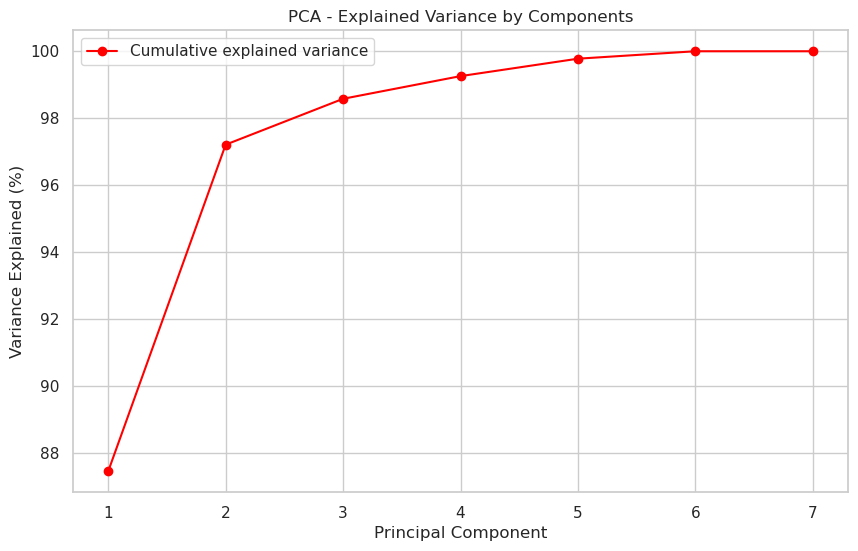

In [153]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

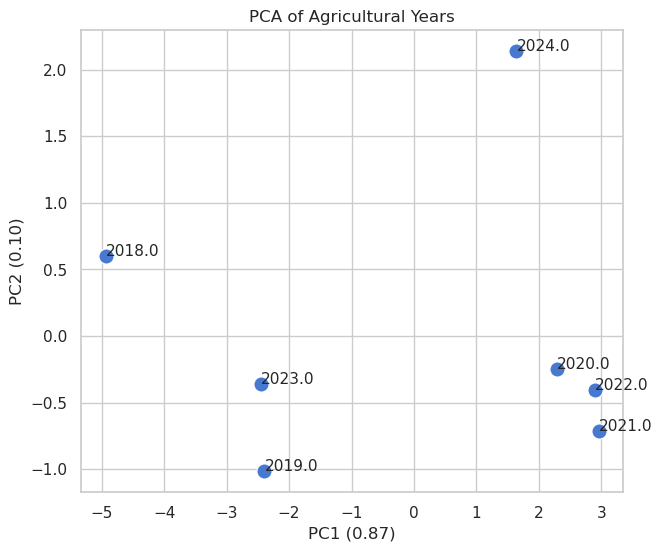

In [154]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
).reset_index()

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=120)

for _, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Ag_year"], fontsize=11)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f})")
plt.title("PCA of Agricultural Years")
plt.show()


In [155]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

print(loadings.sort_values("PC1", ascending=False))

                                  PC1       PC2
NDRE_mean                    0.337753 -0.027020
VW_PC1                       0.332125  0.166444
NDVI_mean                    0.328639  0.174497
root_weighted_soil_moisture  0.327046  0.177389
NDWI_mean                    0.322512  0.081229
precipitation                0.221877  0.749077
cumulative_GDD              -0.298944  0.417249
temperature_2m              -0.319536  0.272961
ST_PC1                      -0.328564  0.214437
Shallow_mean                -0.328611  0.217596


In [156]:
scores = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
print(scores)

              PC1       PC2
Ag_year                    
2018    -4.940777  0.600357
2019    -2.396118 -1.014974
2020     2.287216 -0.247890
2021     2.959403 -0.711425
2022     2.896400 -0.407372
2023    -2.448404 -0.357182
2024     1.642280  2.138486


# Isolation Forest

Isolation Forests are unique in that they provide us with a unassuming ensemble model that evaluates expected path lengths of orthogonal (uniformly split) partitions across the feature space. It can't overfit in the traditional sense since there is no loss function to optimise. For anomalous data, the _path length_ of $x$ (i.e. number of traversals of $x$ along the edges to get to termination node) will consistently be short across the ensemble. This is because an outlier sits very far out in a high dimensional space, so it has a higher probability of being split from the cluster.

In [176]:
features = [
    'NDVI_mean', 
    'NDWI_mean', 
    'NDRE_mean', 
    'volumetric_soil_water_layer_4', 
    'soil_temperature_level_4', 
    'temperature_2m', 
    'temperature_2m_min',
    'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation', 
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    'VW_PC1',
    'Shallow_mean', 
    'ST_PC1'
]

In [179]:
scaler = StandardScaler()
yearly = summary_df.groupby("Ag_year")[features].mean()
X = yearly.copy()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=2000, contamination=3/8, random_state=42)
model.fit(X_scaled)

yearly["anomaly_label"] = model.predict(X_scaled)
yearly["anomaly_score"] = model.decision_function(X_scaled)

In [180]:
yearly

,NDVI_mean,NDWI_mean,NDRE_mean,volumetric_soil_water_layer_4,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,cumulative_GDD,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1,anomaly_label,anomaly_score
Ag_year,,,,,,,,,,,,,,,,,
2018,0.409582,0.067484,0.271515,0.269496,292.168994,290.730678,284.488788,297.818823,2.165307e+07,2.579698,1184.069661,0.287340,-0.395326,293.104618,1.270658,-1,-0.123309
2019,0.429904,0.116318,0.282203,0.267431,292.431620,289.719104,283.698675,296.370739,2.052314e+07,2.250642,1083.418687,0.293197,-0.087123,292.098145,0.889905,-1,-0.016121
2020,0.456460,0.171278,0.299337,0.292303,290.631913,289.138301,283.591951,295.308214,1.966864e+07,2.791385,959.240122,0.377099,0.934913,290.724808,0.341960,1,0.014829
2021,0.462735,0.148522,0.301380,0.308653,290.251654,288.681646,283.197041,294.840797,2.001546e+07,2.872595,906.293887,0.366703,1.035709,290.266056,0.159576,1,0.000280
2022,0.468064,0.164780,0.302569,0.317688,290.721856,288.895480,283.484941,294.869365,1.985941e+07,2.922110,879.621839,0.368016,0.909942,290.645650,0.312125,1,0.032984
2023,0.429436,0.096275,0.281179,0.312609,291.415881,290.256479,284.278600,296.842110,2.044722e+07,2.490008,1058.831572,0.302184,0.069657,292.090782,0.873606,-1,-0.000093
2024,0.468810,0.162550,0.296305,0.315616,291.431012,289.551048,284.130707,295.638164,1.993854e+07,3.431694,1073.633830,0.366058,1.007572,291.419274,0.614860,1,0.001806


The isolation forest therefore beautifully agrees with our conclustion that 2018, 2019 and 2023 are anomaly years.